# Customer Churn Analysis - Week 1 EDA
**Author**: Muhammad Raheel Ijaz
**Date**: 7/19/2026
**Course**: Introduction to Applied AI

## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify patterns and inform our predictive modeling approach.

## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings


In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')


Libraries imported successfully!


In [18]:
# Load data
df = pd.read_csv('customer_data.csv')

# First look
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()


Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,...,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,...,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,...,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,...,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,...,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

In [19]:
# 1.1 Column names and types
print('Column Information:')
df.info()


Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null  

In [20]:
# 1.2 Statistical summary
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [21]:
# 1.3 Check for missing values
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0])

# Fix TotalCharges if needed
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Missing Values:
Series([], dtype: int64)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [22]:
# 1.4 Target variable distribution
print('Churn Distribution:')
print(df['Churn'].value_counts())
print('\nChurn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Key Findings:
- Dataset has 7043 customers
- Churn rate is 26.5%
- 11 missing values in TotalCharges column
- Features include demographics, services, and account info


## 2. Numerical Features Analysis

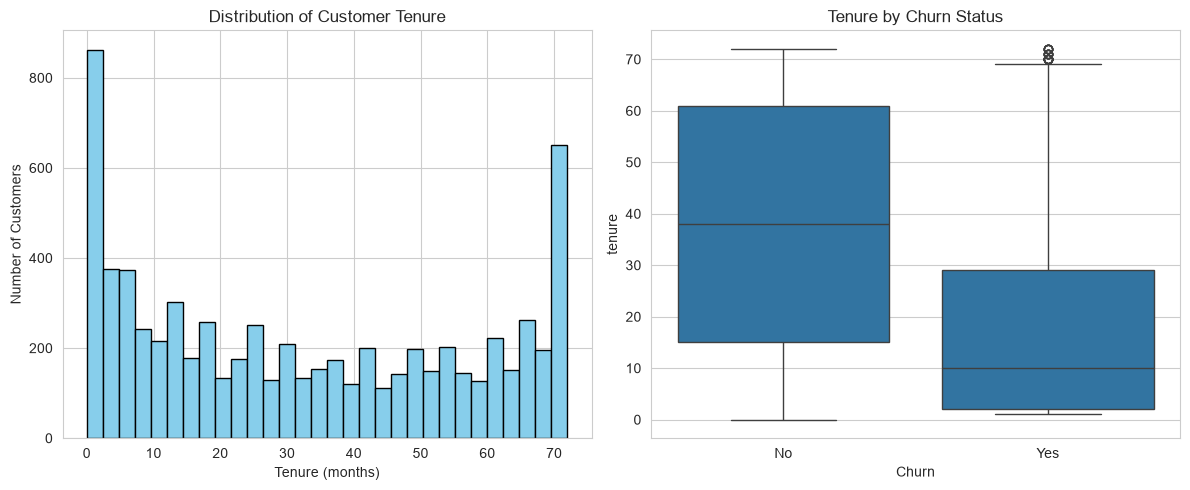

In [23]:
# Visualization 1: Tenure Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')

plt.tight_layout()
plt.show()


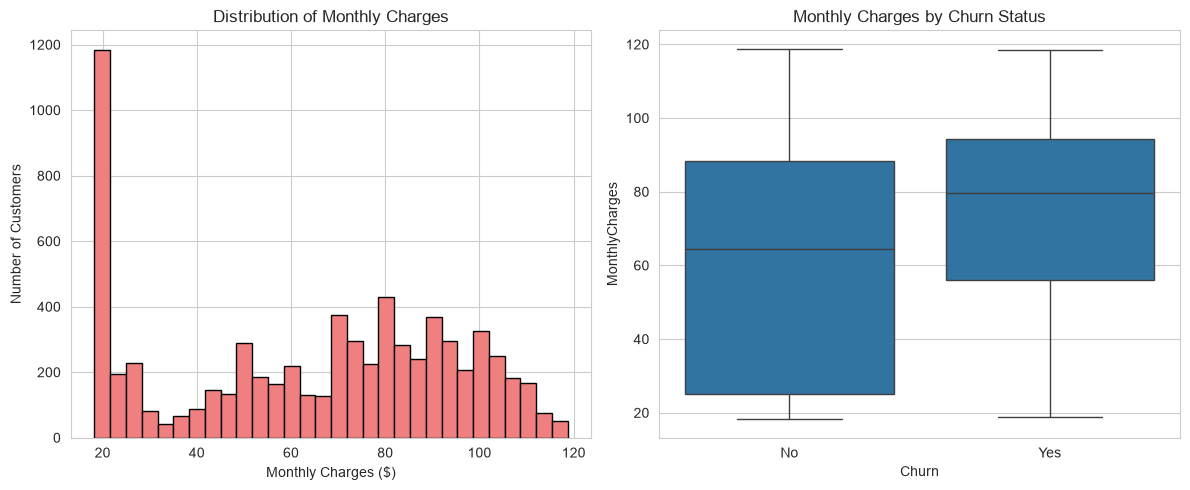

In [24]:
# Visualization 2: Monthly Charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')

plt.tight_layout()
plt.show()


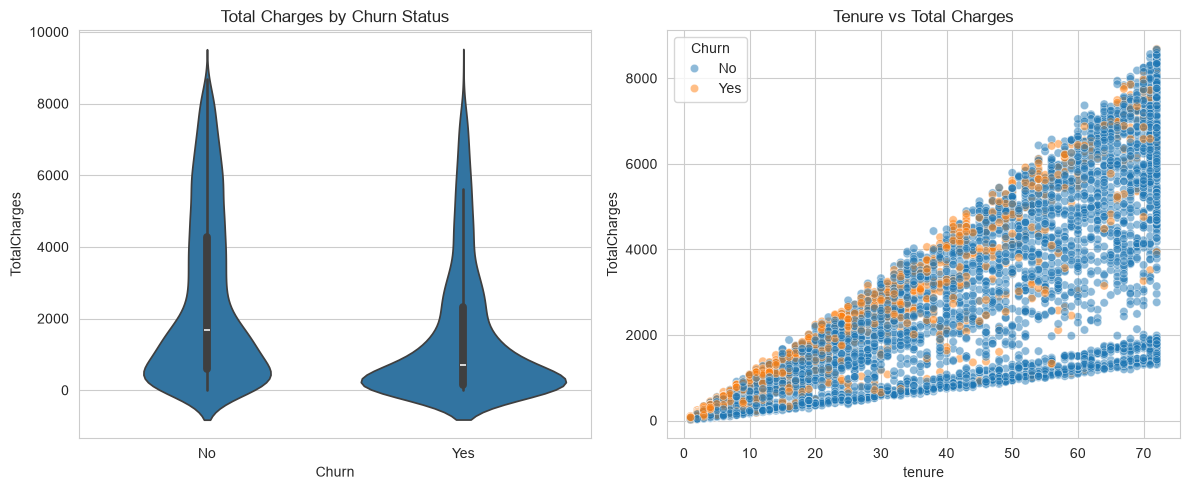

In [25]:
# Visualization 3: Total Charges Analysis
df_clean = df[df['TotalCharges'].notna()]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean)
plt.title('Total Charges by Churn Status')

plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean, alpha=0.5)
plt.title('Tenure vs Total Charges')

plt.tight_layout()
plt.show()


### Numerical Features Insights:
- Tenure: Customers with shorter tenure are more likely to churn
- Monthly Charges: Higher charges correlate with higher churn
- Total Charges: Related to tenure (longer tenure = higher total charges)


## 3. Categorical Features Analysis

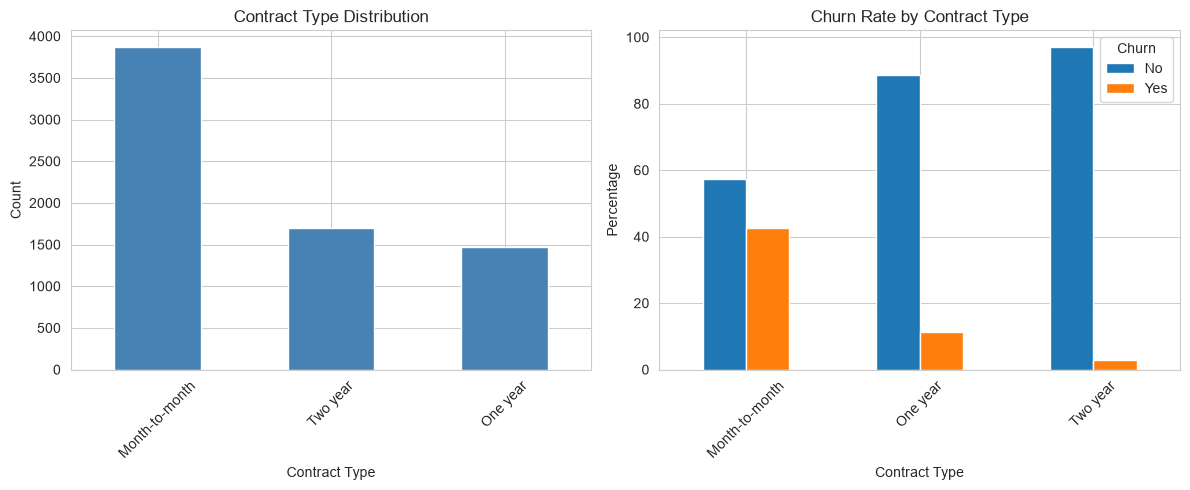

In [26]:
# Visualization 4: Contract Type Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False, ax=plt.gca())
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


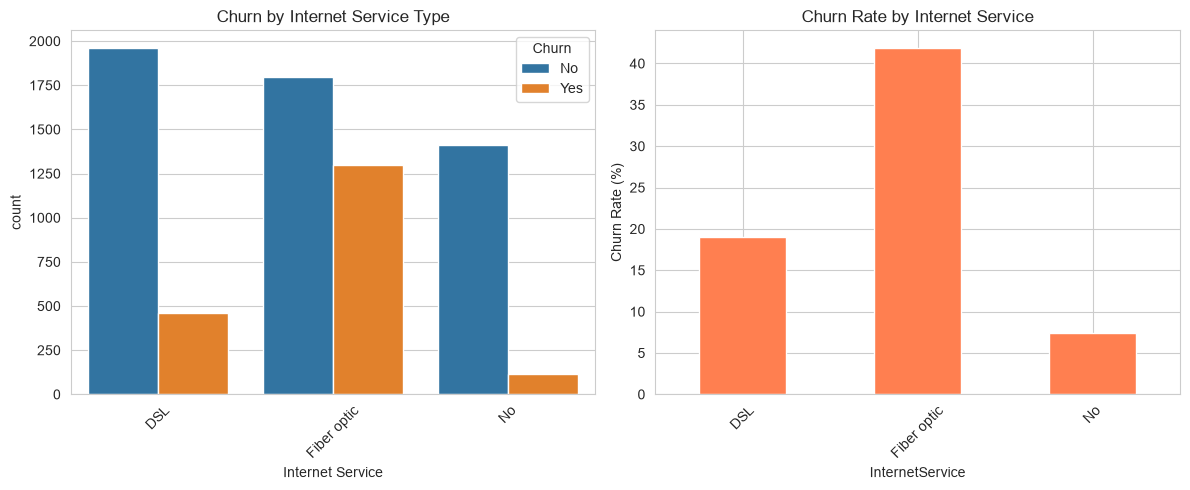

In [27]:
# Visualization 5: Internet Service Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


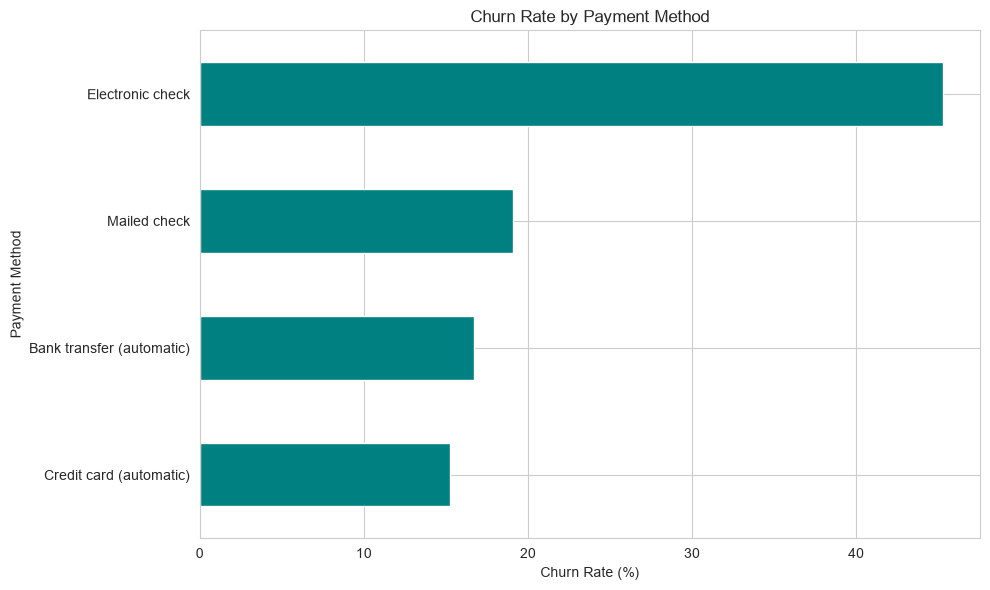

In [28]:
# Visualization 6: Payment Method Analysis
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(10, 6))
payment_churn['Yes'].sort_values().plot(kind='barh', color='teal')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()


## 4. Feature Correlations

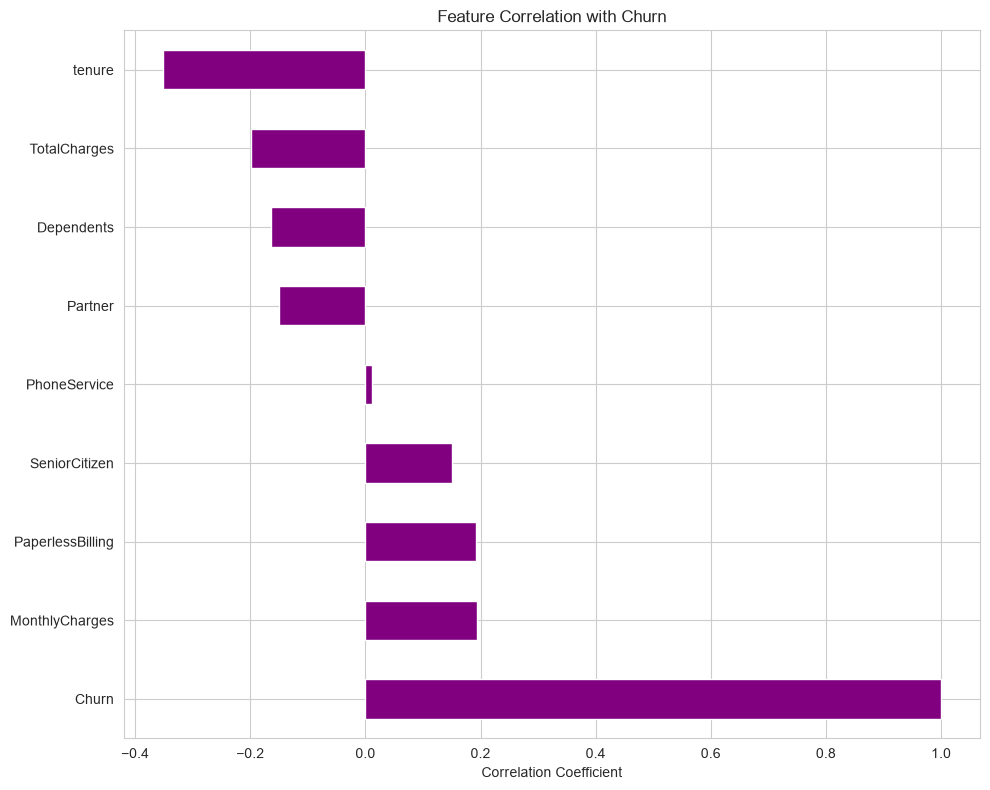

In [29]:
# Prepare numeric data
df_numeric = df.copy()

# Convert Yes/No to 1/0
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})

# Select only numeric columns
numeric_features = df_numeric.select_dtypes(include=[np.number])

# Correlation with Churn
plt.figure(figsize=(10, 8))
churn_corr = numeric_features.corr()['Churn'].sort_values(ascending=False)
churn_corr.plot(kind='barh', color='purple')
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


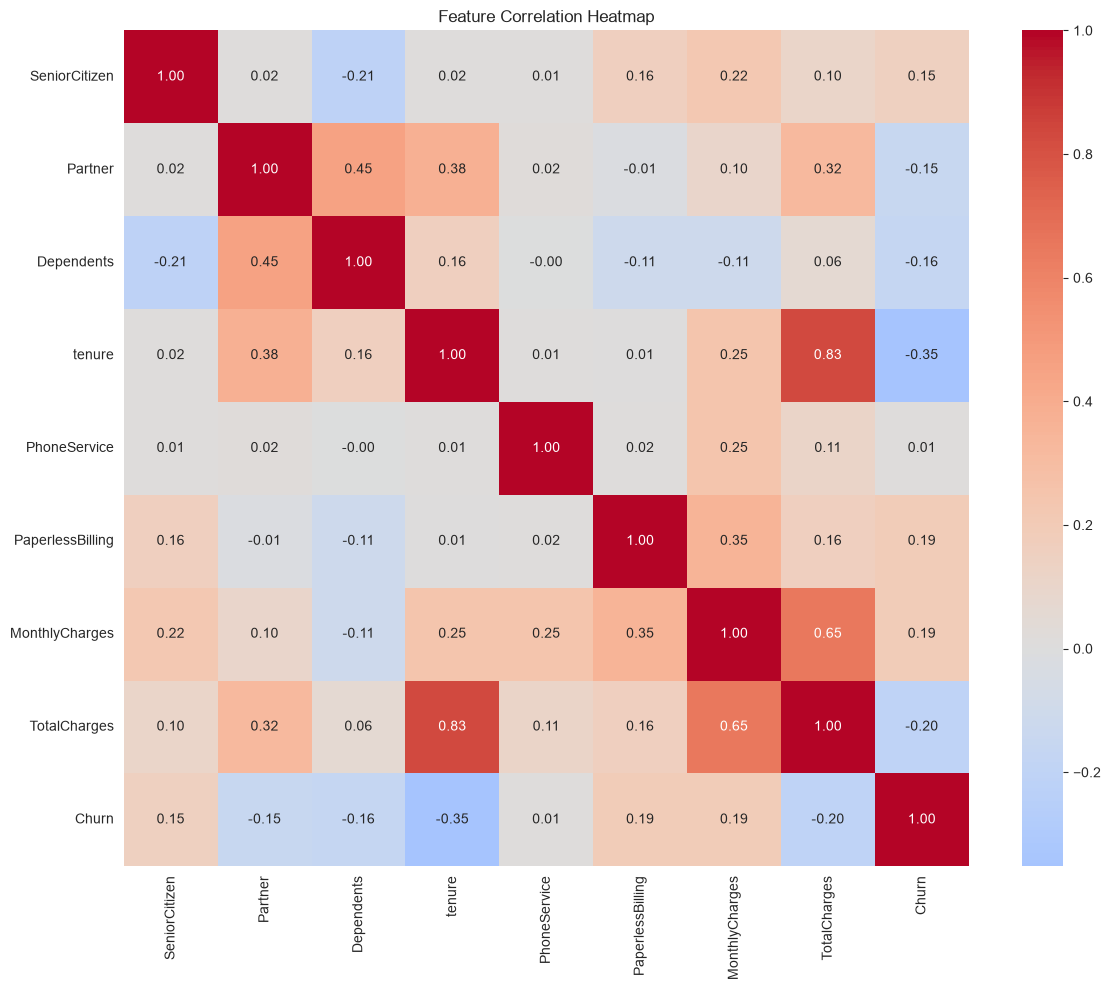

In [30]:
# Full Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 5. Key Insights and Findings

### High-Risk Customer Characteristics:
1. **Contract Type**: Month-to-month contracts have ~43% churn rate (vs ~11% for one-year, ~3% for two-year)
2. **Tenure**: Customers with <6 months tenure are high risk
3. **Charges**: Higher monthly charges correlate with higher churn
4. **Services**: Fiber optic internet users churn more than DSL (~42% vs ~19%)
5. **Payment**: Electronic check users have higher churn (~45%)

### Patterns Observed:
- Customers with tenure under 12 months churn far more often than long-tenure customers
- Month-to-month contracts have a much higher churn rate than one-year or two-year contracts
- Fiber optic internet customers churn more than DSL customers
- Customers paying by electronic check churn more than those using automatic payments
- Monthly charges tend to be higher among customers who churned
### Recommendations for Feature Engineering:
- Create 'TenureGroup' (0-12, 13-24, 25-48, 49+ months)
- Flag 'HighMonthlyCharges' (>$70)
- Count total services subscribed
- Create 'ChargesPerService' ratio

### Questions for Next Week:
- Which features should we include in the model?
- How to handle categorical variables?
- What about class imbalance (if churn rate is low)?
